<a href="https://colab.research.google.com/github/AxisAngeles/Smart_Data_DS_AI/blob/main/S07_Estadistica_para_Modelos_Estadisticos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Unidad 7 – Estadística para Modelos Estadísticos (Repaso + Práctica)
## Enfoque: **Riesgo de Crédito**

**Propósito de la unidad:** pasar de “describir datos” (Unidad 6) a **razonar con incertidumbre** usando probabilidad, distribuciones y conceptos básicos de inferencia que luego conectarán con modelos estadísticos / ML.

---
### ⏱️ Sugerencia de clase (aprox. 2–3 horas, adaptable)
- 20–30 min: teoría guiada + ejemplos cortos
- 60–90 min: práctica y ejercicios en vivo
- 20–30 min: retos para casa + cierre

> **Idea central:** los modelos no entregan certezas → entregan **probabilidades**.


## Contenidos (Unidad 7)
1. Probabilidad (conceptos y reglas básicas)  
2. Teorema de Bayes (intuición y aplicación)  
3. Distribuciones de probabilidad:
   - Discretas: Binomial, Poisson
   - Continuas: Normal, Normal estándar (Z-score)
4. Población vs muestra (intuición para inferencia)  
5. Errores Tipo I y Tipo II (y trade-off)  
6. Nivel de significancia (α) y lectura práctica  


# 0) Setup

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from statistics import NormalDist

np.random.seed(42)


# 1) Dataset base (crédito) para contextualizar ejemplos

Usaremos un dataset **simulado** (8,000 registros) con variables típicas de riesgo.
No entrenaremos modelos aún; lo usaremos para **probabilidad, distribuciones e inferencia básica**.


In [2]:

n = 8000

edad = np.random.randint(18, 70, n)
ingreso_mensual = np.random.lognormal(mean=8.0, sigma=0.45, size=n)
ingreso_mensual = np.clip(ingreso_mensual, 600, 25000)

deuda_mensual = ingreso_mensual * np.random.beta(a=2.0, b=6.0, size=n)
utilizacion_credito = np.random.beta(a=2.0, b=2.5, size=n)
pagos_tarde_12m = np.random.poisson(lam=1.2, size=n)
antiguedad_laboral = np.random.randint(0, 25, n)

monto_prestamo = np.random.lognormal(mean=9.1, sigma=0.55, size=n)
monto_prestamo = np.clip(monto_prestamo, 500, 60000)
plazo_meses = np.random.choice([12, 24, 36, 48, 60], size=n, p=[0.15, 0.25, 0.30, 0.20, 0.10])

tipo_vivienda = np.random.choice(["Alquiler", "Propia", "Familiar", "Hipoteca"], size=n, p=[0.35, 0.30, 0.10, 0.25])
proposito = np.random.choice(["Consumo", "Consolidación", "Vehículo", "Educación", "Emprendimiento"], size=n,
                             p=[0.35, 0.28, 0.15, 0.10, 0.12])

df = pd.DataFrame({
    "edad": edad,
    "ingreso_mensual": np.round(ingreso_mensual, 2),
    "deuda_mensual": np.round(deuda_mensual, 2),
    "utilizacion_credito": np.round(utilizacion_credito, 3),
    "pagos_tarde_12m": pagos_tarde_12m,
    "antiguedad_laboral": antiguedad_laboral,
    "monto_prestamo": np.round(monto_prestamo, 2),
    "plazo_meses": plazo_meses,
    "tipo_vivienda": tipo_vivienda,
    "proposito": proposito
})

df["dti"] = np.round(df["deuda_mensual"] / df["ingreso_mensual"], 3)

# Simular default (probabilidad "verdadera" desconocida en la vida real)
logit = (
    -2.2
    + 3.0 * df["dti"]
    + 1.4 * df["utilizacion_credito"]
    + 0.18 * df["pagos_tarde_12m"]
    - 0.02 * df["antiguedad_laboral"]
    - 0.00003 * df["ingreso_mensual"]
)
p_default = 1 / (1 + np.exp(-logit))
df["default"] = (np.random.rand(n) < p_default).astype(int)

df.head()


,edad,ingreso_mensual,deuda_mensual,utilizacion_credito,pagos_tarde_12m,antiguedad_laboral,monto_prestamo,plazo_meses,tipo_vivienda,proposito,dti,default
0,56,2261.30,704.98,0.490,2,7,8827.34,24,Hipoteca,Emprendimiento,0.312,1
1,69,4543.70,619.13,0.575,2,22,10862.76,48,Alquiler,Educación,0.136,0
2,46,3038.32,1319.91,0.221,1,15,7103.51,24,Alquiler,Consumo,0.434,0
3,32,3816.72,865.47,0.174,1,20,8382.05,60,Propia,Consumo,0.227,0
4,60,5942.73,468.86,0.122,0,22,5992.63,48,Propia,Consumo,0.079,0


### Tasa de default del dataset (para usar como referencia)

In [3]:

df["default"].mean()


np.float64(0.285375)

# 2) Probabilidad (conceptos y reglas básicas)

### 2.1 Eventos en riesgo de crédito
- **Evento A**: “cliente entra en default” (default=1)  
- **Evento B**: “cliente tiene DTI alto” (dti > 0.35)  
- **Evento C**: “cliente tuvo 3+ pagos tarde” (pagos_tarde_12m >= 3)

### 2.2 Probabilidad empírica
En datos, muchas probabilidades se estiman como:
$$
P(A) \approx \frac{\#(A)}{n}
$$

### 2.3 Probabilidad condicional
$$
P(A \mid B) = \frac{P(A \cap B)}{P(B)}
$$

Interpretación:  
$P(A \mid B)$ es la **probabilidad de que el cliente entre en default**
**sabiendo que** tiene un DTI alto.


In [4]:

A = (df["default"] == 1)
B = (df["dti"] > 0.35)
C = (df["pagos_tarde_12m"] >= 3)

P_A = A.mean()
P_B = B.mean()
P_C = C.mean()



P_A, P_B, P_C


(np.float64(0.285375), np.float64(0.241875), np.float64(0.121875))

In [5]:
P_A_and_B = (A & B).mean()

P_A_given_B = P_A_and_B / P_B if P_B > 0 else np.nan

if P_B > 0:
    P_A_given_B = P_A_and_B / P_B
else:
    P_A_given_B = np.nan

P_A_given_B

np.float64(0.41395348837209306)

In [6]:
P_A_and_C = (A & C).mean()
P_A_given_C = P_A_and_C / P_C if P_C > 0 else np.nan
P_A_given_C

np.float64(0.3425641025641026)

### 2.4 Regla de la unión (OR) y la intersección (AND)
- $$P(B \cup C)$$
“DTI alto **o** 3+ pagos tarde”  
- $$P(B \cap C)$$
“DTI alto **y** 3+ pagos tarde”  


In [7]:
# and  &
# or  |

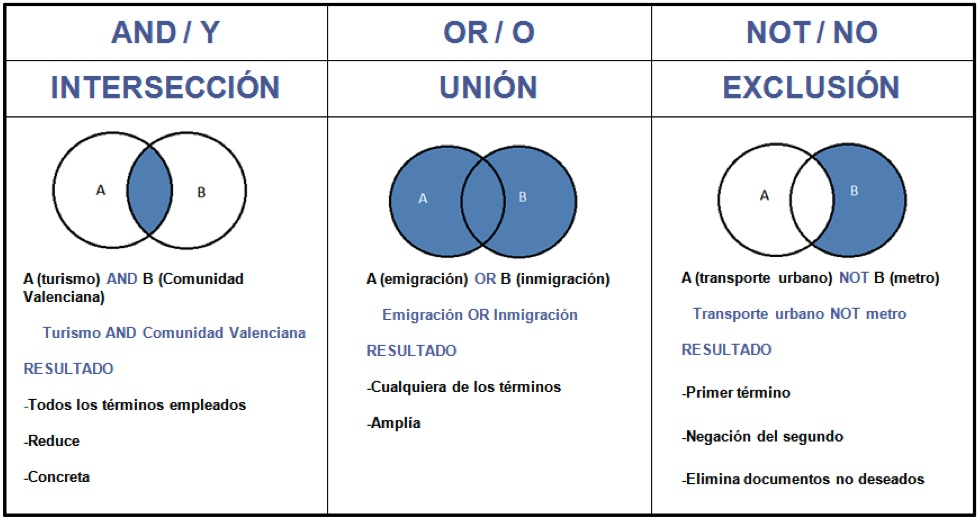

Para A union B, se puede entender como la union del conjunto A y B, restandole la intersección

P(A ∪ B) = P(A) + P(B) - P(A ∩ B)

In [8]:

P_B_or_C = (B | C).mean()
P_B_and_C = (B & C).mean()

P_B_or_C , P_B_and_C


(np.float64(0.33375), np.float64(0.03))

In [9]:
# Verificación de fórmula: P(B ∪ C) = P(B) + P(C) - P(B ∩ C)
P_B_or_C_formula = P_B + P_C - P_B_and_C
P_B_or_C_formula

np.float64(0.33375)

# 3) Teorema de Bayes (intuición + aplicación)

Bayes permite “actualizar” una creencia cuando observamos evidencia:

$$
 P(A \mid B) = \frac{P(B \mid A) P(A)}{P(B)}
$$

En riesgo de crédito, podemos interpretarlo como:
- **A**: el cliente cae en default
- **B**: observamos una señal de riesgo (por ejemplo DTI alto)

> Bayes es muy útil cuando tenemos una tasa base (prior) y una “prueba” o señal (likelihood).


## 3.1 Ejemplo tipo 'test de riesgo'

Supongamos un “alerta de riesgo” que marca clientes como “alto riesgo”.

- P(default) = tasa base de default  
- Sensibilidad = P(alerta=1 | default=1)  
- Especificidad = P(alerta=0 | default=0)  
- Queremos: P(default=1 | alerta=1)

Esto se parece a un test médico, pero aplicado a riesgo.


$$
P(A \mid B) = \frac{P(A \cap B)}{P(B)}
$$

Desglose de fórmula

$$
P(A \mid B)*P(B) = {P(A \cap B)}
$$


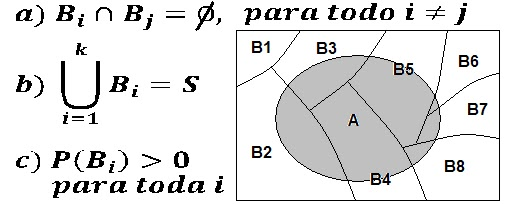

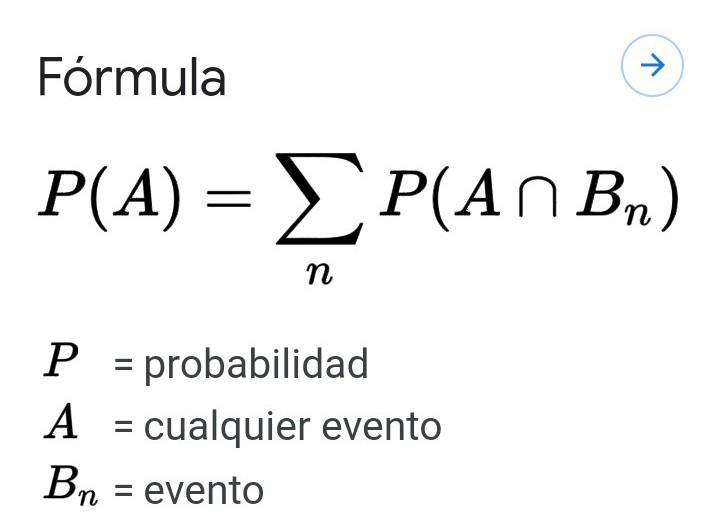

Conjunto B y el conjunto B' son particiones que unidas conforman al universo, y no tienen intersección entre si

In [10]:
# P(A | B) = P(A ∩ B) / P(B)
# B OR not B  = True
# P(A) = P(A & B) + P(A & not B)
# P(A) = P(A | B) * P(B)  + P(A | not B) * P(not B)

In [11]:
# A : alerta = 1
# B: default = 1

# Entonces:
# P(alerta=1) = P(alerta=1|default=1)*P(default=1) + P(alerta=1|default=0)*P(default=0)

In [12]:

# Parámetros hipotéticos de un sistema de alerta
prior = df["default"].mean()          # P(default)
sens = 0.75                           # P(alerta=1 | default=1)  # TP , True Positive , sensibilidad, probabilidad de que la alerta diga que un cliente hará impago a un cliente que hará impago
spec = 0.80                           # P(alerta=0 | default=0)  # TN , True Negativo , especificidad, probabilidad de que la alerta diga que un cliente no hará impago a un cliente que no hará impago

ratio_false_negative = 1-sens
ratio_false_positive = 1-spec
# P(alerta=1) = P(alerta=1|default=1)*P(default=1) + P(alerta=1|default=0)*P(default=0)
p_alerta = sens*prior + (1-spec)*(1-prior)

# Bayes: P(default=1|alerta=1)
p_default_dado_alerta = (sens*prior) / p_alerta

prior, p_alerta, p_default_dado_alerta


(np.float64(0.285375), np.float64(0.35695625), np.float64(0.5996007914135136))

**Interpretación:** incluso con buena sensibilidad/especificidad, si el default es poco frecuente, la probabilidad posterior puede no ser tan alta.
Eso se llama **problema de tasa base**.


# 4) Distribuciones de Probabilidad

En modelos estadísticos, asumimos o aproximamos cómo se distribuyen variables o errores.
Aquí usaremos ejemplos típicos de riesgo de crédito.

## 4.1 Distribución Binomial (discreta)
Modela “n intentos” con éxito/fracaso:
- Ejemplo: en un portafolio de 100 clientes, ¿cuántos caen en default?

## 4.2 Distribución Poisson (discreta)
Modela conteos de eventos raros en un periodo:
- Ejemplo: número de pagos tarde en 12 meses

## 4.3 Distribución Normal (continua)
Modela variables que tienden a concentrarse alrededor de un promedio:
- A veces aproximamos ingresos (tras transformaciones), errores de medición, etc.

## 4.4 Normal estándar y Z-score
Estandariza valores: $$Z = (x-\mu)/\sigma$$. Útil para outliers y probabilidades.


## 4.1 Binomial – Defaults en un mini-portafolio

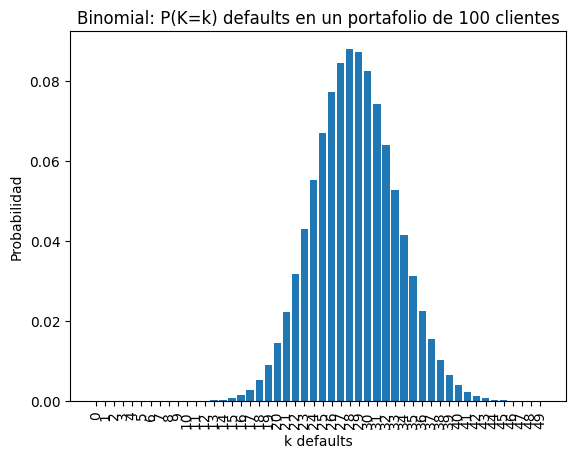

(np.float64(0.9999951248911925), np.float64(0.285375))

In [13]:

def binom_pmf(k, n, p):
    return math.comb(n, k) * (p**k) * ((1-p)**(n-k))

p = df["default"].mean()
n_port = 100

# Probabilidad de EXACTAMENTE k defaults en 100 clientes
ks = list(range(0, 50))
pmf = [binom_pmf(k, n_port, p) for k in ks]

plt.figure()
plt.bar([str(k) for k in ks], pmf)
plt.title("Binomial: P(K=k) defaults en un portafolio de 100 clientes")
plt.xlabel("k defaults")
plt.ylabel("Probabilidad")
plt.xticks(rotation=90)
plt.show()

sum(pmf), p


### Probabilidad de 'al menos 10 defaults' en 100 clientes

In [14]:
prob_ge_10 = sum(binom_pmf(k, n_port, p) for k in range(10, n_port+1))
prob_ge_10

np.float64(0.9999983549311858)

In [15]:

prob_ge_10 = sum(binom_pmf(k, n_port, p) for k in range(20, n_port+1))
prob_ge_10


np.float64(0.9803155642038865)

## 4.2 Poisson – Conteo de pagos tarde

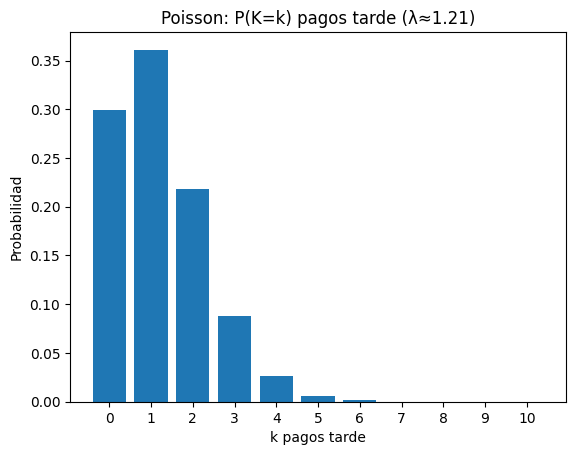

(np.float64(0.9999999346786729), np.float64(1.205875))

In [16]:

# Usaremos la media empírica de pagos tarde como lambda
lam = df["pagos_tarde_12m"].mean()

def poisson_pmf(k, lam):
    return math.exp(-lam) * (lam**k) / math.factorial(k)

ks = list(range(0, 11))
pmf_pois = [poisson_pmf(k, lam) for k in ks]

plt.figure()
plt.bar([str(k) for k in ks], pmf_pois)
plt.title(f"Poisson: P(K=k) pagos tarde (λ≈{lam:.2f})")
plt.xlabel("k pagos tarde")
plt.ylabel("Probabilidad")
plt.show()

sum(pmf_pois), lam


### Probabilidad de tener 3 o más pagos tarde

In [17]:

prob_ge_3 = 1 - sum(poisson_pmf(k, lam) for k in range(0, 3))
prob_ge_3


np.float64(0.12178944082660992)

## 4.3 Normal – Aproximación y probabilidades con Z-score

En la práctica, muchas variables **no** son normales (por ejemplo ingresos suelen ser sesgados).  
Aun así, la Normal es clave para inferencia y estandarización.

Aquí haremos un ejemplo con una variable que suele ser más “normal” tras transformación: `log(ingreso_mensual)`.


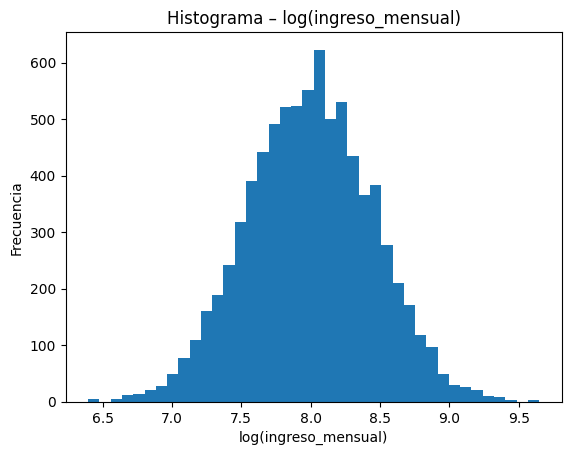

(np.float64(7.995683731117142), 0.4507217419170197)

In [18]:

x = np.log(df["ingreso_mensual"])
mu = x.mean()
sigma = x.std()

plt.figure()
plt.hist(x, bins=40)
plt.title("Histograma – log(ingreso_mensual)")
plt.xlabel("log(ingreso_mensual)")
plt.ylabel("Frecuencia")
plt.show()

mu, sigma


### Probabilidad aproximada: log(ingreso) > mu + 1.5σ

In [19]:

threshold = mu + 1.5*sigma
z = (threshold - mu) / sigma

# P(X > threshold) = 1 - CDF(z)
p_tail = 1 - NormalDist().cdf(z)
z, p_tail


(np.float64(1.499999999999999), 0.0668072012688582)

## 4.4 Z-score aplicado (detección simple de valores extremos)

In [20]:

# Z-scores para log(ingreso)
z_scores = (x - mu) / sigma
extremos = (np.abs(z_scores) > 3).mean()
extremos


np.float64(0.0025)

# 5) Población vs Muestra (intuición para inferencia)

- **Población**: todos los solicitantes posibles (idealmente “infinito” o muy grande).
- **Muestra**: lo que observamos (nuestro dataset).

En la realidad, la muestra puede tener sesgos:
- selección (solo aprobados/solo rechazados)
- ventana temporal (solo 2025)
- cambios de política de crédito

### ¿Por qué importa?
Porque estimamos parámetros de población (promedio, tasa default, etc.) usando una muestra.


## 5.1 Simulación: cómo varía la tasa de default en muestras pequeñas

/tmp/ipykernel_346/1070846477.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([estimates[s] for s in sample_sizes], labels=[str(s) for s in sample_sizes])


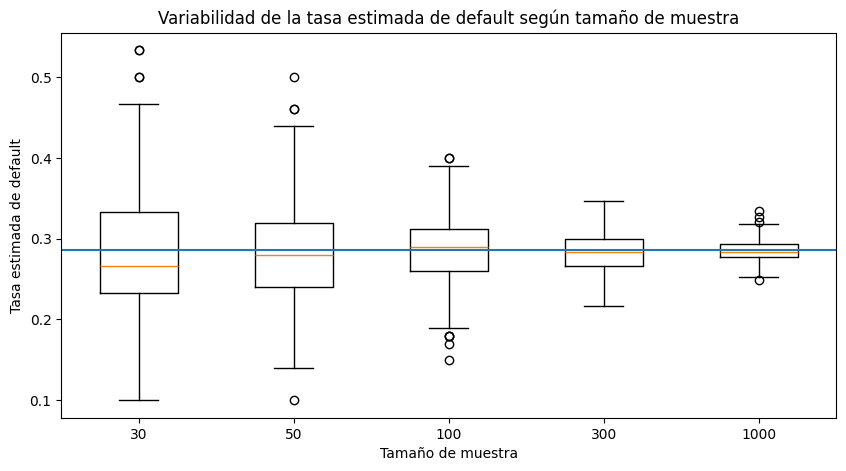

np.float64(0.285375)

In [21]:

true_rate = df["default"].mean()

sample_sizes = [30, 50, 100, 300, 1000]
estimates = {}

for s in sample_sizes:
    est = []
    for _ in range(300):
        est.append(df["default"].sample(s, replace=False).mean())
    estimates[s] = est

# Gráfico: dispersión de estimaciones por tamaño de muestra
plt.figure(figsize=(10,5))
positions = list(range(len(sample_sizes)))
plt.boxplot([estimates[s] for s in sample_sizes], labels=[str(s) for s in sample_sizes])
plt.axhline(true_rate)  # línea de referencia (tasa total)
plt.title("Variabilidad de la tasa estimada de default según tamaño de muestra")
plt.xlabel("Tamaño de muestra")
plt.ylabel("Tasa estimada de default")
plt.show()

true_rate


# 6) Error Tipo I y Tipo II (decisiones y costos en crédito)

Supón una regla de decisión (un “test”) que marca clientes como **riesgosos**.

- **Tipo I (Falso positivo)**: rechazar a un buen cliente (no default)  
- **Tipo II (Falso negativo)**: aprobar a un mal cliente (default)

En crédito, normalmente el Tipo II puede ser más costoso (pérdida), pero depende del negocio.


## 6.1 Ejemplo simple de 'score' (no es modelo, es una regla)

In [22]:

# Regla simple (solo para ilustrar errores):
# Riesgoso si dti>0.35 o pagos_tarde_12m>=3
pred_riesgo = ((df["dti"] > 0.35) | (df["pagos_tarde_12m"] >= 3)).astype(int)
y = df["default"].astype(int)

TP = int(((pred_riesgo==1) & (y==1)).sum())
FP = int(((pred_riesgo==1) & (y==0)).sum())
TN = int(((pred_riesgo==0) & (y==0)).sum())
FN = int(((pred_riesgo==0) & (y==1)).sum())

TP, FP, TN, FN


(1013, 1657, 4060, 1270)

Interpreta:
- FP = Tipo I (rechazados que eran buenos)
- FN = Tipo II (aprobados que eran malos)


In [23]:

tipo_I = FP
tipo_II = FN

precision = TP / (TP + FP) if (TP+FP)>0 else np.nan
recall = TP / (TP + FN) if (TP+FN)>0 else np.nan # sensitivity

tipo_I, tipo_II, precision, recall


(1657, 1270, 0.37940074906367044, 0.4437144108628997)

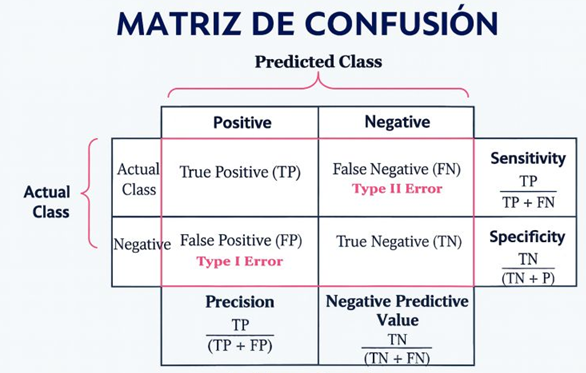

# 7) Nivel de significancia (α) – lectura práctica

En inferencia, α es el umbral para decidir si un resultado es “lo suficientemente raro” como para cuestionar una hipótesis nula.

- α = 0.05 (común): toleras 5% de falsos positivos (Tipo I) en pruebas repetidas.
- En negocio, α puede ajustarse según el costo del error.

⚠️ En esta unidad NO profundizamos en pruebas t completas, pero sí la intuición.


## 7.1 Intuición con un ejemplo de diferencia de promedios (bootstrap simple)

Compararemos el **DTI promedio** entre default=1 y default=0.  
Usaremos un bootstrap simple para ver si la diferencia es “grande” de forma estable.


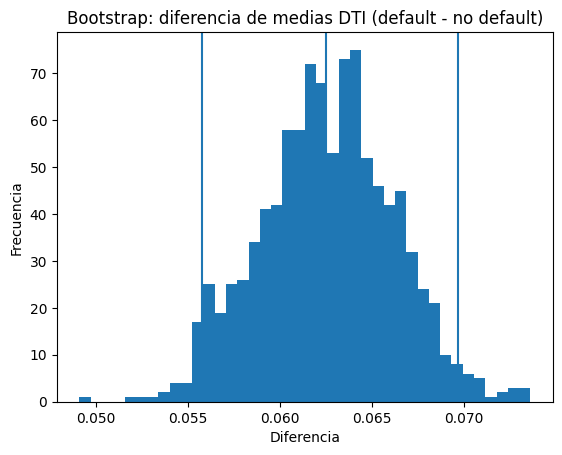

(np.float64(0.06252012552031658),
 (np.float64(0.05576132485695006), np.float64(0.06968121071695935)))

In [24]:

dti_default = df.loc[df["default"]==1, "dti"].values
dti_nodef = df.loc[df["default"]==0, "dti"].values

obs_diff = dti_default.mean() - dti_nodef.mean()

# Bootstrap de la diferencia de medias
B = 1000
diffs = []
for _ in range(B):
    s1 = np.random.choice(dti_default, size=len(dti_default), replace=True)
    s0 = np.random.choice(dti_nodef, size=len(dti_nodef), replace=True)
    diffs.append(s1.mean() - s0.mean())

diffs = np.array(diffs)

# Intervalo 95% (aprox)
low, high = np.quantile(diffs, [0.025, 0.975])

plt.figure()
plt.hist(diffs, bins=40)
plt.title("Bootstrap: diferencia de medias DTI (default - no default)")
plt.xlabel("Diferencia")
plt.ylabel("Frecuencia")
plt.axvline(obs_diff)
plt.axvline(low)
plt.axvline(high)
plt.show()

obs_diff, (low, high)


**Lectura práctica:**  
Si el intervalo 95% no incluye 0, la diferencia es consistentemente distinta de 0 (en términos descriptivo-inferenciales).  
Esto conecta con el espíritu de significancia (sin formalismo pesado aún).


# 🧠 Ejercicios

> Recomendación: en clase resuelve 10–12 ejercicios (⭐). El resto son retos.

---
## 🟢 Probabilidad (Fácil)
1. ⭐ Calcula P(default=1).  
2. ⭐ Calcula P(dti>0.35).  
3. ⭐ Calcula P(default=1 | dti>0.35).  
4. Calcula P(default=1 | pagos_tarde_12m >= 3).  
5. Verifica la fórmula P(B ∪ C)=P(B)+P(C)-P(B ∩ C) para B=(dti>0.35) y C=(pagos_tarde_12m>=3).  
6. Calcula P(default=1 | dti>0.35 y pagos_tarde_12m>=3).

---
## 🟡 Bayes (Medio)
7. ⭐ Define un “alerta de riesgo” con sensibilidad=0.8 y especificidad=0.75. Con la tasa base de tu dataset, calcula P(default | alerta=1).  
8. Repite el ejercicio 7 cambiando la tasa base a 2% (0.02). ¿Qué ocurre? (problema de tasa base).  
9. ⭐ Si un analista cree que P(default)=0.10 en un segmento, pero ve una señal con P(señal|default)=0.7 y P(señal|no default)=0.2, calcula P(default|señal).

---
## 🟡 Distribución Binomial (Medio)
10. ⭐ Usando p = tasa de default, calcula la probabilidad de **al menos 8 defaults** en un portafolio de n=100.  
11. Calcula el valor esperado de defaults en n=200 (E[K]=n·p).  
12. Grafica la PMF binomial para n=50 y comenta dónde se concentra la masa.

---
## 🟡 Distribución Poisson (Medio)
13. ⭐ Usa λ = promedio de pagos_tarde_12m. Calcula P(K≥3).  
14. Calcula P(K=0) y P(K=1). Interpreta en negocio.  
15. Grafica la PMF Poisson para k=0..15.

---
## 🟡 Normal y Z-score (Medio)
16. ⭐ Calcula z-score para un umbral de log(ingreso) y estima P(X>umbral) usando la CDF normal.  
17. Calcula qué % de registros tienen |z|>3 en log(ingreso).  
18. (Opcional) Compara histogramas de ingreso vs log(ingreso) y comenta cuál se ve más “normal”.

---
## 🟡 Población vs muestra (Medio)
19. ⭐ Toma 5 muestras de tamaño 50 y calcula la tasa de default en cada una. Compara con la tasa total.  
20. Repite con tamaño 500. ¿Qué cambia?  
21. Grafica un boxplot de tasas estimadas para tamaños [30, 100, 300, 1000].

---
## 🟡 Tipo I / Tipo II (Medio)
22. ⭐ Define una regla: riesgo=1 si dti>0.35. Calcula TP, FP, TN, FN.  
23. Cambia umbral a dti>0.25 y repite. ¿Qué pasa con FP y FN?  
24. ⭐ Asigna costos: FP=1, FN=5. Calcula costo total en ambos umbrales (0.35 vs 0.25). ¿Cuál conviene?  
25. (Opcional) Calcula precision y recall para ambos umbrales.

---
## 🔥 Retos para casa (manteniendo nivel “amigable”)
26. Diseña una regla de riesgo con 2 variables (p.ej. dti y pagos_tarde_12m) y compara errores Tipo I/II vs la regla original.  
27. Implementa una función `binom_cdf_ge(k, n, p)` que devuelva P(K≥k).  
28. Implementa una función `poisson_cdf_ge(k, lam)` que devuelva P(K≥k).  
29. Crea bins de DTI y estima P(default | bin) para cada bin. Grafícalo.  
30. Haz un mini-reporte (markdown) de 10 líneas: ¿qué aprendiste sobre incertidumbre y decisiones en crédito?

# Solución Ejercicios

## 1. Probabilidad (Fácil)
- Calcula P(default=1).
- Calcula P(dti>0.35).
- Calcula P(default=1 | dti>0.35).
- Calcula P(default=1 | pagos_tarde_12m >= 3).
- Verifica la fórmula P(B ∪ C)=P(B)+P(C)-P(B ∩ C) para B=(dti>0.35) y C=(pagos_tarde_12m>=3).
- Calcula P(default=1 | dti>0.35 y pagos_tarde_12m>=3).

In [28]:
# 1) Probabilidad (Fácil)

print(f'1.1 : {(df['default'] == 1).mean()}')
print(f'1.2 : {(df['dti'] > .35).mean()}')
print(f'1.3 : {((df['default'] == 1)|(df['dti'] > .35)).mean()}')
print(f'1.4 : {((df['default'] == 1)|(df['pagos_tarde_12m'] >= 3)).mean()}')

print('\n1.5 : P(B ∪ C) = P(B) + P(C) -P(B ∩ C)')
B = (df['dti'] > .35).mean()
C = (df['pagos_tarde_12m'] >= 3).mean()
D = ((df['dti'] > .35)|(df['pagos_tarde_12m'] >= 3)).mean()
E = ((df['dti'] > .35)&(df['pagos_tarde_12m'] >= 3)).mean()
print(f'B = {B} & C = {C} & P(B ∪ C) = {D} & P(B ∩ C) = {E}')

print(f'\nP(B ∪ C) = {((df['dti'] > .35)|(df['pagos_tarde_12m'] >= 3)).mean()}')
print(f'P(B) + P(C) -P(B ∩ C) = {B+C-E}')
print('Se verifica la fórmula')

print(f'1.6 : {(((df['default'] == 1)|(df['dti'] > .35))&(df['pagos_tarde_12m'] >= 3)).mean()}')

1.1 : 0.285375
1.2 : 0.241875
1.3 : 0.427125
1.4 : 0.3655

1.5 : P(B ∪ C) = P(B) + P(C) -P(B ∩ C)
B = 0.241875 & C = 0.121875 & P(B ∪ C) = 0.33375 & P(B ∩ C) = 0.03

P(B ∪ C) = 0.33375
P(B) + P(C) -P(B ∩ C) = 0.33375
Se verifica la fórmula
1.6 : 0.0565


 ## 2. Bayes (Medio)
- Define un “alerta de riesgo” con sensibilidad=0.8 y especificidad=0.75. Con la tasa base de tu dataset, calcula P(default | alerta=1).
- Repite el ejercicio 7 cambiando la tasa base a 2% (0.02). ¿Qué ocurre? (problema de tasa base).
- Si un analista cree que P(default)=0.10 en un segmento, pero ve una señal con P(señal|default)=0.7 y P(señal|no default)=0.2, calcula P(default|señal).

$$
P(A \mid B) = \frac{P(A \cap B)}{P(B)}
$$

$$
P(A \mid B)*P(B) = {P(A \cap B)}
$$

- **A**: el cliente cae en default
- **B**: observamos una señal de riesgo (por ejemplo DTI alto)

In [36]:
# 2) Bayes (Medio)
prob_default = (df['default'] == 1).mean() # BASE
sens = 0.80 # True Positive (TP)
spec = 0.75 # True Negative (TN)

# P(alerta=1) = P(alerta=1|default=1)*P(default=1) + P(alerta=1|default=0)*P(default=0)
p_alerta = sens * prob_default + (1 - spec) * (1 - prob_default)

# Bayes: P(default=1|alerta=1)
p_default_dado_alerta = (sens*prob_default) / p_alerta

print('2.1')
print(f'Probabilidad de default: {prob_default:.2f}')
print(f'Probabilidad de alerta: {p_alerta:.2f}')
print(f'BAYES: Prob de default, dada la alerta: {p_default_dado_alerta:.2f}')
#Interpretación: Hay un 56% de probabilidad de caer en default si se emite la alerta, misma que tiene una probabilidad de 41% de ocurrir.


print('\n2.2')
prob_default_2 = 0.02
p_alerta = sens * prob_default_2 + (1 - spec) * (1 - prob_default_2)
p_default_dado_alerta = (sens*prob_default_2) / p_alerta
print(f'Probabilidad de default: {prob_default_2:.2f}')
print(f'Probabilidad de alerta: {p_alerta:.2f}')
print(f'BAYES: Prob de default, dada la alerta: {p_default_dado_alerta:.2f}')
#Interpretación: Al disminuir la tasa base a 2% (muy bajo), la probabilidad posterior (P(default=1|alerta=1)) permanece baja.


print('\n2.3')
prob_default_3 = 0.10
sens = 0.7
FP = 0.2
p_alerta = sens * prob_default_3 + FP * (1 - prob_default_3)
p_default_dado_alerta = (sens*prob_default_3) / p_alerta
print(f'Probabilidad de default: {prob_default_3:.2f}')
print(f'Probabilidad de alerta: {p_alerta:.2f}')
print(f'BAYES: Prob de default, dada la alerta: {p_default_dado_alerta:.2f}')


2.1
Probabilidad de default: 0.29
Probabilidad de alerta: 0.41
BAYES: Prob de default, dada la alerta: 0.56

2.2
Probabilidad de default: 0.02
Probabilidad de alerta: 0.26
BAYES: Prob de default, dada la alerta: 0.06

2.3
Probabilidad de default: 0.10
Probabilidad de alerta: 0.25
BAYES: Prob de default, dada la alerta: 0.28


## Distribución Binomial (Medio)
- Usando p = tasa de default, calcula la probabilidad de al menos 8 defaults en un portafolio de n=100.
- Calcula el valor esperado de defaults en n=200 (E[K]=n·p).
- Grafica la PMF binomial para n=50 y comenta dónde se concentra la masa.

3.1
Probabilidad de al menos 8 defaults: 0.999999919098186
Probabilidad de al menos 8 defaults: 0.9999999190981912

3.2
Valor esperado de defaults en n=200: 57.0



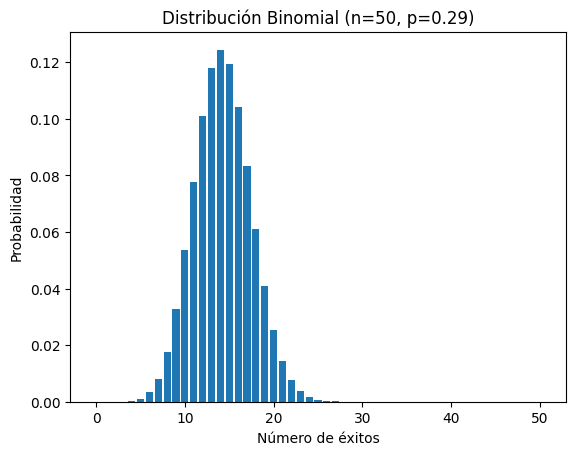

In [78]:
# 1) Librerías math (para Coeficiente Binomial)
import math
import numpy as np
import matplotlib.pyplot as plt

# 2) Crear función de proba binomial
def binomial_pmf(k, n, p):
    return math.comb(n, k) * (p**k) * ((1-p)**(n-k))

# 3.1 probabilidad de al menos 8 defaults
print(f'3.1')
p = df['default'].mean()

# Calcular la probabilidad de 1 a 7 defaults
proba_defaults = []

for i in range(8):
  val = binomial_pmf(i,100,p)
  proba_defaults.append(val)

proba_defaults = np.array(proba_defaults)
p_1a7_def = proba_defaults.sum()

print(f'Probabilidad de al menos 8 defaults: {1-p_1a7_def}')


# ----------------------------------  FORMA PRO DE RESOLVERLO ------------------------------
prob_ge_8 = sum(binom_pmf(k, 100, p) for k in range(8, 101))
print(f'Probabilidad de al menos 8 defaults: {prob_ge_8}')
# ------------------------------------------------------------------------------------------


# 3.2 Valor esperado de defaults
print(f'\n3.2')
print(f'Valor esperado de defaults en n=200: {round(200*p,0)}\n')


# 3.3 Gráfica
ks = list(range(51))
probs = [binomial_pmf(k,50,p) for k in ks]


plt.figure()
plt.bar(ks,probs)
plt.title(f"Distribución Binomial (n=50, p={p:.2f})")
plt.xlabel("Número de éxitos")
plt.ylabel("Probabilidad")
# plt.bar_label(probs, fmt='%.2f')

plt.show()


In [27]:
df

,edad,ingreso_mensual,deuda_mensual,utilizacion_credito,pagos_tarde_12m,antiguedad_laboral,monto_prestamo,plazo_meses,tipo_vivienda,proposito,dti,default
0,56,2261.30,704.98,0.490,2,7,8827.34,24,Hipoteca,Emprendimiento,0.312,1
1,69,4543.70,619.13,0.575,2,22,10862.76,48,Alquiler,Educación,0.136,0
2,46,3038.32,1319.91,0.221,1,15,7103.51,24,Alquiler,Consumo,0.434,0
3,32,3816.72,865.47,0.174,1,20,8382.05,60,Propia,Consumo,0.227,0
4,60,5942.73,468.86,0.122,0,22,5992.63,48,Propia,Consumo,0.079,0
...,...,...,...,...,...,...,...,...,...,...,...,...
7995,21,2890.17,431.88,0.329,3,20,11799.07,36,Alquiler,Emprendimiento,0.149,1
7996,43,1770.54,287.17,0.248,0,10,6403.65,36,Propia,Consolidación,0.162,0
7997,28,4971.23,1250.83,0.556,2,3,2509.45,48,Propia,Consumo,0.252,0
7998,19,2015.35,791.08,0.680,1,21,8854.18,12,Familiar,Vehículo,0.393,0


# ✅ Cierre de la Unidad 7

Hoy conectaste:
- Probabilidad y probabilidad condicional (base para scoring y modelos)
- Bayes (actualización de creencias y problema de tasa base)
- Distribuciones (binomial/poisson/normal) para razonar sobre eventos y variabilidad
- Población vs muestra (variabilidad de estimación)
- Errores Tipo I y II (trade-offs y costos)
- Intuición de significancia (α) como control de falsos positivos

**Próximo paso natural:** usar estas ideas para evaluar modelos (métricas) y comprender inferencia en modelos estadísticos.
